# m01_rank — Conviction Engine

**Edge**: Post-breakout 20-day continuation in tight-ATR consolidations. The
binary collapse (Home Run vs Rest) focuses XGBoost's loss on separating
elite setups from everything else, instead of spending capacity on the
arbitrary boundary between Solid and Strong.

**Target**: `y_homerun = (close.shift(-20) / close - 1) > 0.20`, computed
per ticker on dense `t3_sepa_features`.

**Horizon**: 20 trading days. Chosen because (a) it matches the SEPA
holding-period median, (b) shorter horizons amplify microstructure noise,
(c) longer horizons widen the survivorship aperture too much.

**Strategy gating**: cross-sectional rank (daily top-K), NOT absolute
probability threshold. → G4 Branch B applies; ECE is informational, not
blocking.

**Expected positive rate**: 5–8% (verified by sensitivity table below).


### Imports + path setup

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from src.evaluation.training_data_loader import load_pretrain_data
from src.evaluation.data_quality import warmup_clip, run_quality_gate
from src.evaluation.leakage_guard import LeakageGuard
from src.evaluation.feature_signal import (
    compute_ic, compute_mutual_information, compute_redundancy,
)
from src.evaluation.pretrain_report import _select_feature_cols

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)


### G0 target construction + sensitivity sweep

In [2]:
df_full = load_pretrain_data(mode="dense")
df = df_full[(df_full["date"] >= "2018-01-01") & (df_full["date"] <= "2024-12-31")].copy()
del df_full

df = df.sort_values(["ticker", "date"])
df = warmup_clip(df)
print(f"Rows after warmup clip: {len(df):,}")

def add_forward_returns(d, horizons=(5, 10, 20, 60)):
    g = d.groupby("ticker", group_keys=False)
    for h in horizons:
        d[f"return_{h}d_fwd"] = g["close"].shift(-h) / d["close"] - 1.0
    return d

df = add_forward_returns(df)

# Sensitivity table — pick the (horizon, threshold) where positive rate is 5–15%
# AND IC of the top-5 features stays comparable across adjacent cells.
def sensitivity(d, horizons=(5, 10, 20, 60), thresholds=(0.10, 0.15, 0.20, 0.30)):
    rows = []
    for h in horizons:
        col = f"return_{h}d_fwd"
        valid = d[col].notna().sum()
        for t in thresholds:
            y = (d[col] > t)
            rows.append({"horizon_d": h, "threshold": t,
                         "pos_rate": float(y.mean()),
                         "n_pos": int(y.sum()),
                         "n_valid": int(valid)})
    return pd.DataFrame(rows)

sens = sensitivity(df)
print(sens.pivot(index="horizon_d", columns="threshold", values="pos_rate").round(3))

# Lock the chosen target (matches the notebook header)
HORIZON, THRESHOLD = 20, 0.20
df["y_homerun"] = (df[f"return_{HORIZON}d_fwd"] > THRESHOLD).astype(int)
df = df.dropna(subset=[f"return_{HORIZON}d_fwd"])
print(f"\nPositive rate at h={HORIZON}, t={THRESHOLD}: {df['y_homerun'].mean():.1%}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

INFO:src.evaluation.training_data_loader:Loaded t3_sepa_features: 9303500 rows x 144 cols (mode=dense)
INFO:src.evaluation.data_quality:warmup_clip: 3674699 -> 3477067 rows (dropped 197632 leading-NULL)


Rows after warmup clip: 3,477,067
threshold   0.10   0.15   0.20   0.30
horizon_d                            
5          0.053  0.023  0.012  0.004
10         0.101  0.050  0.027  0.010
20         0.173  0.099  0.060  0.026
60         0.297  0.214  0.154  0.084

Positive rate at h=20, t=0.2: 6.1%


### G1 data lineage + leakage scan

In [9]:
# Strip every column that could leak the future, then verify with LeakageGuard
FORWARD_RETURN_COLS = [c for c in df.columns if c.endswith("_fwd")]
LEAKAGE_EXTRAS = {"y_homerun", "mfe_pct", "mae_pct", "days_observed",
                  "return_1d", "return_5d", "return_20d", "return_60d"}

candidate_feats = _select_feature_cols(df)
feature_cols = [f for f in candidate_feats
                if f not in LEAKAGE_EXTRAS and f not in FORWARD_RETURN_COLS]
print(f"Feature columns after exclusion: {len(feature_cols)}")

# Quality gate — must PASS
qa = run_quality_gate(df, feature_cols, mode="dense")
print(f"\nQuality gate: {'PASS' if qa.passed else 'FAIL'}")
if not qa.passed:
    print("Action required:")
    for a in qa.action_required:
        print(" ", a)
    raise RuntimeError("G1 failed — fix upstream before continuing")

# Independent leakage backstop
flagged = LeakageGuard().check_feature_leakage(feature_cols)
print(f"\nLeakageGuard flagged: {flagged}")
assert not flagged['num_suspicious'], "G1 failed — leakage detected"

Feature columns after exclusion: 131


INFO:src.evaluation.leakage_guard:✅ No suspicious features detected (131 features checked)
INFO:src.evaluation.leakage_guard:✅ No suspicious features detected (131 features checked)



Quality gate: PASS

LeakageGuard flagged: {'is_clean': True, 'suspicious_features': [], 'num_suspicious': 0, 'num_features': 131, 'message': '✅ No suspicious features detected (131 features checked)'}


### G2 signal (IC + MI + redundancy)

In [10]:
# Run on the TRAINING WINDOW only — keep the held-out slice untouched.
HELDOUT_CUTOFF = pd.Timestamp("2024-01-01")
df_train_full = df[df["date"] < HELDOUT_CUTOFF].copy()
print(f"Training-window rows: {len(df_train_full):,}")

# IC — full df is fine; the slow O(N log N) is inside spearmanr, manageable.
t = time.time()
ic_df = compute_ic(df_train_full, feature_cols, target="y_homerun")
print(f"IC: {time.time()-t:.1f}s")
display(ic_df.head(15))

# MI — internally samples to 20k rows; runs in seconds.
t = time.time()
mi_df = compute_mutual_information(df_train_full, feature_cols, target="y_homerun")
print(f"MI: {time.time()-t:.1f}s")
display(mi_df.head(15))

# Redundancy — fast path (rank + Pearson + 200k sample) lives in compute_redundancy
t = time.time()
corr, redundant = compute_redundancy(df_train_full, feature_cols, threshold=0.80)
print(f"Redundancy: {time.time()-t:.1f}s  pairs>|0.80|={len(redundant)}")
display(pd.DataFrame(redundant[:15], columns=["a", "b", "abs_corr"]))

# G2 gate
strong = ic_df[ic_df["abs_ic"] > 0.05]
print(f"\nG2 gate: {len(strong)} features with |IC|>0.05")
assert len(strong) >= 5, "G2 failed — not enough signal in features"


Training-window rows: 2,908,434
IC: 66.7s


,feature,spearman_ic,pval,abs_ic,low_signal
0,adr_20d,0.248633,0.0,0.248633,False
1,natr,0.245521,0.0,0.245521,False
2,consolidation_width,0.214413,0.0,0.214413,False
3,dist_from_52w_high,-0.183866,0.0,0.183866,False
4,pct_from_high_52w,-0.183866,0.0,0.183866,False
5,low_52w,-0.163365,0.0,0.163365,False
6,lowest_low_20d,-0.153104,0.0,0.153104,False
7,dist_from_20d_high,-0.151688,0.0,0.151688,False
8,ema_8,-0.144122,0.0,0.144122,False
9,sma_20,-0.142046,0.0,0.142046,False


MI: 10.2s


,feature,mi_score
0,adr_20d,0.034598
1,m03_pillar_trend,0.033890
2,natr,0.033344
3,m03_regime_vol,0.030887
4,m03_pillar_risk,0.027078
5,consolidation_width,0.025264
6,m03_pillar_liq,0.022719
7,pct_from_high_52w,0.021531
8,dist_from_52w_high,0.021479
9,m03_score,0.018068


Redundancy: 10.6s  pairs>|0.80|=285


,a,b,abs_corr
0,price_vs_spy,rs_line_log,1.000000
1,dist_from_52w_high,pct_from_high_52w,1.000000
2,dist_from_52w_low,pct_above_low_52w,1.000000
3,price_momentum_curve,immediate_thrust,1.000000
4,rs_rating,rs_universe_rank,0.999948
5,sma_20,ema_21,0.999870
6,vol_avg_20,vol_ma20,0.999867
7,high_20d,highest_high_20d,0.999768
8,vol_avg_50,vol_ma50,0.999752
9,sma_50,ema_50,0.999654



G2 gate: 52 features with |IC|>0.05


In [32]:
# G2b — per-ticker IC, averaged across tickers (equal weight)
def ticker_grouped_ic(d, feature_cols, target, min_obs=30):
    from scipy import stats
    recs = []
    for feat in feature_cols:
        if not pd.api.types.is_numeric_dtype(d[feat]):
            continue
        ics = []
        for _, g in d.groupby("ticker"):
            s = g[[feat, target]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(s) >= min_obs and s[feat].nunique() > 1:
                ics.append(stats.spearmanr(s[feat], s[target]).correlation)
        if ics:
            recs.append({"feature": feat, "ic_ticker_mean": float(np.nanmean(ics)),
                         "ic_ticker_std": float(np.nanstd(ics)), "n_tickers": len(ics)})
    return (pd.DataFrame(recs)
            .assign(abs_ic=lambda x: x["ic_ticker_mean"].abs())
            .sort_values("abs_ic", ascending=False).reset_index(drop=True))

ic_grouped = ticker_grouped_ic(df_train_full, feature_cols, "y_homerun")
display(ic_grouped.head(15))
# Compare ordering vs pooled ic_df. Features that fall out of the top on the
# grouped view were riding label-mass concentration, not cross-ticker signal.

C:\Users\Hang\AppData\Local\Temp\ipykernel_45308\3944092177.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ics.append(stats.spearmanr(s[feat], s[target]).correlation)
C:\Users\Hang\AppData\Local\Temp\ipykernel_45308\3944092177.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ics.append(stats.spearmanr(s[feat], s[target]).correlation)
C:\Users\Hang\AppData\Local\Temp\ipykernel_45308\3944092177.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ics.append(stats.spearmanr(s[feat], s[target]).correlation)
C:\Users\Hang\AppData\Local\Temp\ipykernel_45308\3944092177.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ics.append(stats.spearmanr(s[feat], s[target]).correlation)
C:\Users\Hang\AppData\Local\Temp\ipykernel_45308\3944092177.py:12: ConstantInputWarning: An input array is c

,feature,ic_ticker_mean,ic_ticker_std,n_tickers,abs_ic
0,pct_from_high_52w,-0.140237,0.127701,2462,0.140237
1,m03_pillar_risk,-0.135431,0.117284,2462,0.135431
2,low_52w,-0.131110,0.124501,2438,0.131110
3,rs,-0.126519,0.117289,2462,0.126519
4,adr_20d,0.124425,0.125770,2462,0.124425
5,turnover_ma20,0.114827,0.126371,2462,0.114827
6,rs_vs_industry,-0.106865,0.117338,2458,0.106865
7,ema_21_50_ratio,-0.102635,0.118657,2462,0.102635
8,m03_score,-0.094539,0.100057,2462,0.094539
9,dist_from_20d_high,-0.087973,0.100052,2462,0.087973


### Prune redundant features

In [11]:
# Default rule: for each redundant pair, keep the one with the higher MI score.
mi_lookup = mi_df.set_index("feature")["mi_score"].to_dict()
to_drop = set()
for a, b, _ in redundant:
    if a in to_drop or b in to_drop:
        continue
    if mi_lookup.get(a, 0) < mi_lookup.get(b, 0):
        to_drop.add(a)
    else:
        to_drop.add(b)

feature_cols = [f for f in feature_cols if f not in to_drop]
print(f"Dropped {len(to_drop)} redundant features; {len(feature_cols)} remain")


Dropped 55 redundant features; 76 remain


### G3 walk-forward fit (≥4 expanding folds)

In [12]:
def expanding_walk_forward(d, feature_cols, target, folds):
    """folds = [(train_end, test_start, test_end), ...] — date strings."""
    from sklearn.metrics import roc_auc_score, average_precision_score
    out = []
    for train_end, test_start, test_end in folds:
        tr = d[d["date"] <  pd.Timestamp(train_end)]
        te = d[(d["date"] >= pd.Timestamp(test_start)) &
               (d["date"] <= pd.Timestamp(test_end))]
        Xtr, ytr = tr[feature_cols].copy(), tr[target]
        Xte, yte = te[feature_cols].copy(), te[target]
        for c in Xtr.select_dtypes(include=["object", "category"]).columns:
            Xtr[c] = Xtr[c].astype("category")
            Xte[c] = Xte[c].astype("category")
        spw = (len(ytr) - ytr.sum()) / (ytr.sum() + 1e-5)
        m = xgb.XGBClassifier(
            objective="binary:logistic", n_estimators=100, max_depth=4,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw, enable_categorical=True,
            tree_method="hist", random_state=42,
        )
        m.fit(Xtr, ytr)
        p = m.predict_proba(Xte)[:, 1]
        out.append({
            "fold": f"{test_start[:7]}->{test_end[:7]}",
            "n_train": len(ytr), "n_test": len(yte),
            "base_rate": float(yte.mean()),
            "roc_auc": roc_auc_score(yte, p),
            "pr_auc": average_precision_score(yte, p),
        })
    return pd.DataFrame(out)

# Four expanding folds. 2022 fold MUST be present — it's the drawdown stress test.
FOLDS = [
    ("2020-01-01", "2020-01-01", "2020-12-31"),
    ("2021-01-01", "2021-01-01", "2021-12-31"),
    ("2022-01-01", "2022-01-01", "2022-12-31"),  # drawdown regime — critical
    ("2023-01-01", "2023-01-01", "2023-12-31"),
]
wf = expanding_walk_forward(df_train_full, feature_cols, "y_homerun", FOLDS)
display(wf)

print(f"\nMean ROC-AUC: {wf['roc_auc'].mean():.3f}  |  "
      f"Min: {wf['roc_auc'].min():.3f}  |  Std: {wf['roc_auc'].std():.3f}")
assert wf["roc_auc"].min() > 0.65, \
    "G3 failed — model collapses in at least one fold (check the 2022 row)"


,fold,n_train,n_test,base_rate,roc_auc,pr_auc
0,2020-01->2020-12,852574,467272,0.125161,0.775200,0.307177
1,2021-01->2021-12,1319846,502046,0.047014,0.784776,0.143308
2,2022-01->2022-12,1821892,537934,0.063472,0.794553,0.181653
3,2023-01->2023-12,2359826,548608,0.060974,0.793242,0.192010



Mean ROC-AUC: 0.787  |  Min: 0.775  |  Std: 0.009


In [31]:
# G3b — ticker-grouped AUC alongside per-row AUC
from sklearn.metrics import roc_auc_score

def ticker_grouped_auc(d, feature_cols, target, folds, min_rows=20, min_pos=2):
    """Per-fold: fit on train, then AUC computed PER TICKER and averaged
    (equal weight per ticker), vs the pooled per-row AUC."""
    rows = []
    for train_end, test_start, test_end in folds:
        tr = d[d["date"] < pd.Timestamp(train_end)]
        te = d[(d["date"] >= pd.Timestamp(test_start)) &
               (d["date"] <= pd.Timestamp(test_end))]
        Xtr, ytr = tr[feature_cols].copy(), tr[target]
        Xte = te[feature_cols].copy()
        for c in Xtr.select_dtypes(include=["object", "category"]).columns:
            Xtr[c] = Xtr[c].astype("category"); Xte[c] = Xte[c].astype("category")
        spw = (len(ytr) - ytr.sum()) / (ytr.sum() + 1e-5)
        m = xgb.XGBClassifier(objective="binary:logistic", n_estimators=100,
            max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw, enable_categorical=True, tree_method="hist",
            random_state=42)
        m.fit(Xtr, ytr)
        te = te.assign(_p=m.predict_proba(Xte)[:, 1])
        pooled = roc_auc_score(te[target], te["_p"])
        per_tkr = []
        for _, g in te.groupby("ticker"):
            if len(g) >= min_rows and min_pos <= g[target].sum() <= len(g) - min_pos:
                per_tkr.append(roc_auc_score(g[target], g["_p"]))
        rows.append({"fold": f"{test_start[:7]}->{test_end[:7]}",
                     "auc_pooled": pooled,
                     "auc_ticker_mean": float(np.mean(per_tkr)) if per_tkr else np.nan,
                     "n_tickers_scored": len(per_tkr)})
    return pd.DataFrame(rows)

wf_grouped = ticker_grouped_auc(df_train_full, feature_cols, "y_homerun", FOLDS)
display(wf_grouped)
# Verdict signal: if auc_ticker_mean << auc_pooled, the headline AUC is
# carried by a few long-lived tickers, not broad cross-sectional skill.


,fold,auc_pooled,auc_ticker_mean,n_tickers_scored
0,2020-01->2020-12,0.775200,0.720751,1860
1,2021-01->2021-12,0.784776,0.610182,1282
2,2022-01->2022-12,0.794553,0.672750,1645
3,2023-01->2023-12,0.793242,0.617433,1483


### Refit on full training window (for G4–G6)

In [13]:
TRAIN_END  = pd.Timestamp("2023-01-01")
VALID_END  = pd.Timestamp("2024-01-01")    # the sacred cutoff
df_train = df_train_full[df_train_full["date"] <  TRAIN_END].copy()
df_valid = df_train_full[df_train_full["date"] >= TRAIN_END].copy()
print(f"Train: {len(df_train):,}  |  Validation: {len(df_valid):,}")

X_train, y_train = df_train[feature_cols].copy(), df_train["y_homerun"]
X_valid, y_valid = df_valid[feature_cols].copy(), df_valid["y_homerun"]
for c in X_train.select_dtypes(include=["object", "category"]).columns:
    X_train[c] = X_train[c].astype("category")
    X_valid[c] = X_valid[c].astype("category")

spw = (len(y_train) - y_train.sum()) / (y_train.sum() + 1e-5)
model = xgb.XGBClassifier(
    objective="binary:logistic", n_estimators=100, max_depth=4,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, enable_categorical=True,
    tree_method="hist", random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=20)

p_valid = model.predict_proba(X_valid)[:, 1]


Train: 2,359,826  |  Validation: 548,608
[0]	validation_0-logloss:0.67512
[20]	validation_0-logloss:0.51074
[40]	validation_0-logloss:0.46511
[60]	validation_0-logloss:0.44868
[80]	validation_0-logloss:0.43968
[99]	validation_0-logloss:0.43478


### G4 calibration / rank-stability (Branch B per Cell 0)

Strategy gates on **rank**, not absolute probability. So calibration is informational;
the hard pass is **rank stability**.

ECE (informational, since we use rank gating): 0.252


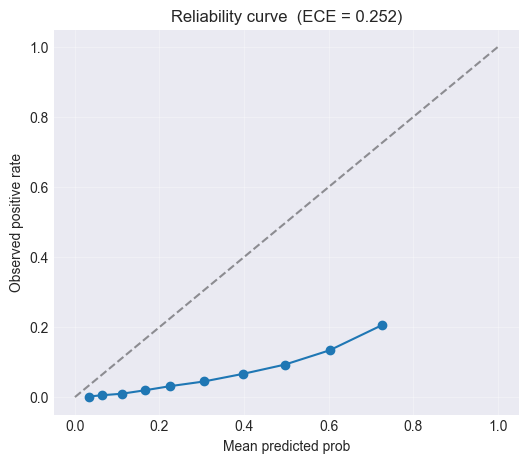


Rank-stability  median: 0.996  mean: 0.996


In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve

# Informational: how bad is the raw probability?
frac_pos, mean_pred = calibration_curve(y_valid, p_valid, n_bins=10, strategy="quantile")
ece = float(np.mean(np.abs(frac_pos - mean_pred)))
print(f"ECE (informational, since we use rank gating): {ece:.3f}")

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.plot(mean_pred, frac_pos, marker="o")
plt.xlabel("Mean predicted prob"); plt.ylabel("Observed positive rate")
plt.title(f"Reliability curve  (ECE = {ece:.3f})")
plt.grid(alpha=0.3); plt.show()

# THE HARD GATE — rank stability across consecutive days.
scored = df_valid[["date", "ticker"]].copy()
scored["prob"] = p_valid
scored["daily_rank"] = scored.groupby("date")["prob"].rank(pct=True)

# Day-to-day rank correlation per ticker (Spearman of (daily_rank_t, daily_rank_{t-1}))
wide = scored.pivot_table(index="date", columns="ticker", values="daily_rank")
day_to_day_corr = wide.corrwith(wide.shift(1), axis=1, method="spearman").dropna()
print(f"\nRank-stability  median: {day_to_day_corr.median():.3f}  "
      f"mean: {day_to_day_corr.mean():.3f}")
assert day_to_day_corr.mean() > 0.50, \
    "G4 (Branch B) failed — daily rank order is too unstable to gate on"


In [19]:
# ── G4 (Branch B): rank stability + feature freshness ────────────────────────
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve

# Informational: calibration (we gate on rank, not absolute prob)
frac_pos, mean_pred = calibration_curve(y_valid, p_valid, n_bins=10, strategy="quantile")
ece = float(np.mean(np.abs(frac_pos - mean_pred)))
print(f"ECE (informational): {ece:.3f}\n")

# Build daily-ranked scored frame
scored = df_valid[["date", "ticker"]].copy()
scored["prob"] = p_valid
scored["daily_rank"] = scored.groupby("date")["prob"].rank(pct=True)

# ── Diagnostic 1: cross-sectional rank consistency (what 0.996 actually was) ──
# Across consecutive days, do the same tickers occupy the same percentile band?
wide = scored.pivot_table(index="date", columns="ticker", values="daily_rank")
xs_corr = wide.corrwith(wide.shift(1), axis=1, method="spearman").dropna()
print(f"Cross-sectional rank consistency  median: {xs_corr.median():.3f}")

# ── Diagnostic 2: top-K turnover (the operationally meaningful metric) ────────
# Of yesterday's top-K, how many drop out of today's top-K? Low turnover = stable
# screen + low transaction cost. High turnover = noise.
def topk_turnover(scored, k=20):
    daily = scored.sort_values(["date", "prob"], ascending=[True, False])
    daily_topk = daily.groupby("date").head(k).groupby("date")["ticker"].apply(set)
    out = []
    for i in range(1, len(daily_topk)):
        a, b = daily_topk.iloc[i-1], daily_topk.iloc[i]
        out.append(len(a - b) / k)             # % of yesterday's top-K that left
    return pd.Series(out).mean()

for k in [10, 20, 50]:
    print(f"  Top-{k} daily churn: {topk_turnover(scored, k):.1%}")

# ── Diagnostic 3: feature freshness (the question I actually wanted to ask) ───
# How fast do the dominant features move? If the top-5 SHAP features all move
# <2% per day, the model literally cannot re-evaluate faster than that.
top_drivers = shap_imp.head(5).index.tolist()
print(f"\nFeature freshness (median |d/d %chg|, larger = fresher):")
for f in top_drivers:
    if f not in df_valid.columns: continue
    pc = df_valid.sort_values(["ticker","date"]).groupby("ticker")[f].pct_change().abs()
    print(f"  {f:30s}  {pc.median()*100:>6.2f}%  (95th pct: {pc.quantile(0.95)*100:.1f}%)")

# ── Diagnostic 4: score persistence (the real "does the model think today?") ──
# Spearman of each ticker's own score across consecutive days.
# Low = noisy/responsive; High = sticky/static. 0.95+ means screen, not model.
per_ticker = (scored.sort_values(["ticker","date"])
                    .groupby("ticker")["prob"]
                    .apply(lambda s: s.corr(s.shift(1)))
                    .dropna())
print(f"\nPer-ticker score persistence  median: {per_ticker.median():.3f}  "
      f"(>0.95 = static screen, 0.7–0.9 = stable model, <0.5 = noisy)")


ECE (informational): 0.252

Cross-sectional rank consistency  median: 0.996
  Top-10 daily churn: 13.2%
  Top-20 daily churn: 11.3%
  Top-50 daily churn: 8.4%

Feature freshness (median |d/d %chg|, larger = fresher):
  adr_20d                           1.66%  (95th pct: 6.6%)
  low_52w                           0.00%  (95th pct: 0.0%)
  pct_from_high_52w                 4.88%  (95th pct: 90.9%)
  m03_pillar_risk                   2.60%  (95th pct: 11.7%)
  atr_20d                           1.66%  (95th pct: 7.0%)

Per-ticker score persistence  median: 0.940  (>0.95 = static screen, 0.7–0.9 = stable model, <0.5 = noisy)


In [34]:
# G4b — permuted-feature null baseline for rank persistence
# Permute features WITHIN ticker (Open Q5 -> within-ticker): preserves each
# name's marginal feature distribution but destroys the feature->return link,
# so any residual persistence is pure feature autocorrelation, not signal.
rng = np.random.default_rng(42)
Xnull = X_valid.copy()
idx = df_valid.reset_index().groupby("ticker").indices
for col in Xnull.columns:
    for _, pos in idx.items():
        Xnull.iloc[pos, Xnull.columns.get_loc(col)] = \
            Xnull.iloc[pos, Xnull.columns.get_loc(col)].sample(frac=1, random_state=int(rng.integers(1e9))).values
p_null = model.predict_proba(Xnull)[:, 1]
sn = df_valid[["date", "ticker"]].copy(); sn["prob"] = p_null
sn["daily_rank"] = sn.groupby("date")["prob"].rank(pct=True)
wn = sn.pivot_table(index="date", columns="ticker", values="daily_rank")
null_corr = wn.corrwith(wn.shift(1), axis=1, method="spearman").dropna()
print(f"Persistence  real: {day_to_day_corr.mean():.3f}  "
      f"null(within-ticker perm): {null_corr.mean():.3f}")
# Verdict: real >> null  -> persistence is model skill.
#          real ~= null  -> persistence is just slow features; metric uninformative.


Persistence  real: 0.996  null(within-ticker perm): 0.879


### G5 attribution (Gain vs SHAP)

In [15]:
import shap

gain = pd.Series(model.get_booster().get_score(importance_type="gain"),
                 name="gain").sort_values(ascending=False)
print("Top 15 by Gain:"); display(gain.head(15).to_frame())

# SHAP on a 500-row sample of high-confidence predictions
hi = X_valid.iloc[np.argsort(-p_valid)[:500]]
sv = shap.TreeExplainer(model).shap_values(hi)
shap_imp = pd.Series(np.abs(sv).mean(0), index=hi.columns,
                     name="mean_abs_shap").sort_values(ascending=False)
print("\nTop 15 by SHAP (high-confidence sample):"); display(shap_imp.head(15).to_frame())

# G5 gate
top5_gain = set(gain.head(5).index)
top5_shap = set(shap_imp.head(5).index)
overlap = len(top5_gain & top5_shap)
print(f"\nTop-5 Gain ∩ SHAP overlap: {overlap} / 5")
assert overlap >= 3, "G5 failed — drivers disagree across methods (investigate)"

top5_ic = set(ic_df.head(20)["feature"])
in_ic = sum(f in top5_ic for f in top5_shap)
print(f"Top-5 SHAP in IC top-20: {in_ic} / 5")
assert in_ic >= 3, "G5 failed — SHAP drivers don't match the IC story"


Top 15 by Gain:


,gain
adr_20d,53406.621094
pct_from_high_52w,10910.999023
low_52w,8343.990234
dist_from_20d_high,7552.303223
pct_above_low_52w,5352.204102
m03_pillar_risk,5195.260742
rs,4977.957520
mom_slope_21_63,4290.448730
m03_pillar_liq,3509.074219
sma_ratio_150_200,3202.247559



Top 15 by SHAP (high-confidence sample):


,mean_abs_shap
adr_20d,0.873893
low_52w,0.494223
pct_from_high_52w,0.484860
m03_pillar_risk,0.176424
atr_20d,0.161898
m03_pillar_trend,0.053073
pct_above_low_52w,0.050591
m03_pillar_liq,0.043203
rs,0.042454
m03_regime_vol,0.024210



Top-5 Gain ∩ SHAP overlap: 3 / 5
Top-5 SHAP in IC top-20: 4 / 5


In [33]:
# G5b — block-subsampled SHAP control (1 row per ticker per 20d block)
import shap
blk = df_train.assign(_blk=lambda d: d.groupby("ticker").cumcount() // 20)
thin = blk.groupby(["ticker", "_blk"], group_keys=False).head(1)
Xth, yth = thin[feature_cols].copy(), thin["y_homerun"]
for c in Xth.select_dtypes(include=["object", "category"]).columns:
    Xth[c] = Xth[c].astype("category")
spw = (len(yth) - yth.sum()) / (yth.sum() + 1e-5)
m_thin = xgb.XGBClassifier(objective="binary:logistic", n_estimators=100,
    max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, enable_categorical=True, tree_method="hist",
    random_state=42).fit(Xth, yth)
sv_thin = shap.TreeExplainer(m_thin).shap_values(Xth.sample(min(2000, len(Xth)),
                                                            random_state=42))
shap_thin = pd.Series(np.abs(sv_thin).mean(0), index=feature_cols,
                      name="shap_thinned").sort_values(ascending=False)
print("SHAP ranking on block-thinned data (dense artifact removed):")
display(shap_thin.head(15).to_frame())
# Verdict: if adr_20d drops from 5x-peer to peer-level here, its G5 dominance
# is a duplication artifact, not economic signal.


SHAP ranking on block-thinned data (dense artifact removed):


,shap_thinned
adr_20d,1.002083
m03_pillar_risk,0.198500
low_52w,0.170594
pct_from_high_52w,0.150415
m03_pillar_trend,0.115662
pct_above_low_52w,0.082594
vcp_ratio,0.064301
m03_regime_vol,0.041384
dollar_volume_avg_20,0.037217
m03_delta_20d,0.029733


In [28]:
# ── Leakage stress test 1: shuffle the target, retrain, backtest ─────────────
# If a model trained on SHUFFLED y_homerun still produces positive backtest
# results, the features carry information about the timing of returns that
# they shouldn't (look-ahead). Pure noise model should give nav_sharpe ~ 0.
import xgboost as xgb
np.random.seed(123)
y_shuffled = pd.Series(np.random.permutation(y_train.values), index=y_train.index)
m_noise = xgb.XGBClassifier(
    objective="binary:logistic", n_estimators=100, max_depth=4,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, enable_categorical=True, tree_method="hist",
    random_state=42,
).fit(X_train, y_shuffled)
p_noise = m_noise.predict_proba(X_valid)[:, 1]
sc_noise = df_valid[["date","ticker",f"return_{HORIZON}d_fwd"]].copy()
sc_noise.columns = ["date","ticker","fwd_return"]
sc_noise["prob"] = p_noise
sc_noise = sc_noise.dropna(subset=["fwd_return"])
_, stats_noise, _ = portfolio_backtest(sc_noise, hold_days=HORIZON,
                                        prob_enter=0.5, consec=3, top_k=3)
print(f"NOISE MODEL backtest: {stats_noise}")
# nav_sharpe should be ~0 (or even negative). If it's > 1, features leak.

# ── Leakage stress test 2: shift features back by 5 days, retrain, score ────
# If using features from 5 days BEFORE entry destroys the signal completely,
# the model is depending on day-of-entry information that may include
# inadvertent forward-looking pollution.
df_train_shifted = df_train.sort_values(['ticker','date']).copy()
for f in feature_cols:
    df_train_shifted[f] = df_train_shifted.groupby('ticker')[f].shift(5)
df_train_shifted = df_train_shifted.dropna(subset=feature_cols[:5])  # any few

Xtr_s = df_train_shifted[feature_cols].copy()
ytr_s = df_train_shifted["y_homerun"]
for c in Xtr_s.select_dtypes(include=["object","category"]).columns:
    Xtr_s[c] = Xtr_s[c].astype("category")
m_shifted = xgb.XGBClassifier(
    objective="binary:logistic", n_estimators=100, max_depth=4,
    learning_rate=0.05, scale_pos_weight=spw,
    enable_categorical=True, tree_method="hist", random_state=42,
).fit(Xtr_s, ytr_s)

df_valid_shifted = df_valid.sort_values(['ticker','date']).copy()
for f in feature_cols:
    df_valid_shifted[f] = df_valid_shifted.groupby('ticker')[f].shift(5)
Xv_s = df_valid_shifted[feature_cols].copy()
for c in Xv_s.select_dtypes(include=["object","category"]).columns:
    Xv_s[c] = Xv_s[c].astype("category")
from sklearn.metrics import roc_auc_score
p_s = m_shifted.predict_proba(Xv_s)[:, 1]
mask = ~p_s.__class__(np.isnan(p_s)) if False else ~np.isnan(p_s)
yv_s = df_valid_shifted["y_homerun"].values
keep = (~np.isnan(p_s)) & (~pd.isna(yv_s))
print(f"AUC with 5-day-lagged features: {roc_auc_score(yv_s[keep], p_s[keep]):.3f}")
# If AUC stays > 0.70 with 5-day lag, model is using slow features (expected).
# If AUC collapses to 0.55, model depended on day-of features that may leak.


NOISE MODEL backtest: {'n_trades': 39, 'avg_trade_ret': 0.00047260165156493006, 'win_rate': 0.5384615384615384, 'ann_per_slot': 0.005971130684703008, 'total_ret_nav': -0.14216698469496947, 'nav_sharpe': -2.087431533229478}


TypeError: object of type 'numpy.bool' has no len()

### G6 non-overlapping vectorised backtest

**Read this before you trust any number from this cell:**

The strategy holds **K equal-weighted slots in parallel**. When a slot frees, the
highest-ranked eligible candidate fills it. We only have the *total* 20-day
return per trade (not the day-by-day OHLCV path), so each trade's total return is
**spread uniformly across its `hold_days` holding window** as a constant daily
compounded equivalent. This is a path-smoothing approximation — it loses
intra-trade drawdown shape but it is the right model for capital-sharing,
overlapping trades and gives a Sharpe computed from a real portfolio NAV.

What this cell deliberately does NOT compute, and why:

- ❌ **`(1 + trade_ret).prod()` across trades.** Wrong by construction: multiple
  concurrent trades share capital, they don't compound each other's returns. With
  ~500 trades averaging 15% each that formula returns ~10¹⁴, a math artefact, not
  a P&L.
- ❌ **Sharpe of the trade-return series.** Each trade is a 20-day outcome, not a
  daily P&L event — Sharpe of that series is inflated by `sqrt(252)` against a
  natural denominator of `sqrt(252/20)`.

What this cell *does* compute:

- ✅ `avg_trade_ret` — equal-weighted average per-trade 20d return (already net of cost).
- ✅ `ann_per_slot` — annualised return per capital slot, the right unit-economics number.
- ✅ `nav_sharpe` — Sharpe of the portfolio's daily NAV series (the honest one).
- ✅ `total_ret_nav` — total compounded return of the K-slot portfolio (the honest one).


,prob_enter,top_k,n_trades,avg_trade_ret,win_rate,ann_per_slot,total_ret_nav,nav_sharpe
0,0.5,2,496,0.153117,0.546371,5.020128,9.827581e+06,10.536336
1,0.5,3,744,0.114766,0.509409,2.931092,6.066176e+04,8.413244
2,0.5,5,1240,0.086762,0.506452,1.852950,1.354983e+03,5.096886
3,0.6,2,496,0.151910,0.554435,4.941163,9.924729e+06,10.503590
4,0.6,3,744,0.111381,0.512097,2.783307,3.707357e+04,7.877648
5,0.6,5,1240,0.083754,0.505645,1.755024,8.090675e+02,4.821578
6,0.7,2,496,0.152972,0.556452,5.010565,1.330103e+07,10.808169
7,0.7,3,737,0.111424,0.518318,2.785176,4.005034e+04,8.298320
8,0.7,5,1197,0.098490,0.517962,2.266092,1.265766e+04,6.943097


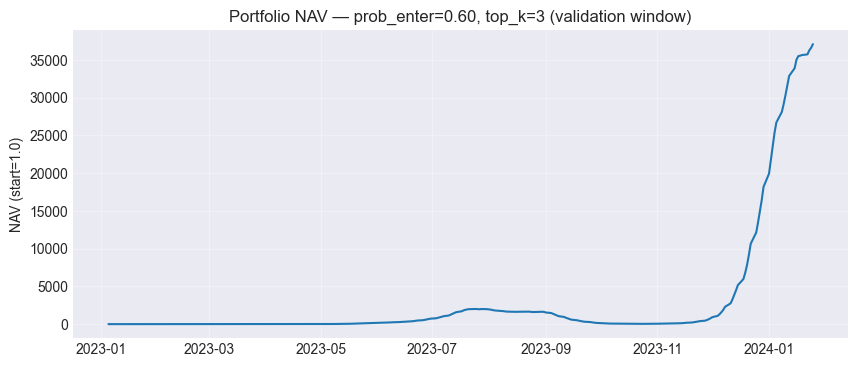


G6 gate: 9 / 9 cells beat (avg_trade_ret>0, nav_sharpe>1)


In [18]:
def vectorized_backtest_nonoverlap(scored, hold_days=20, prob_enter=0.60,
                                    consec=3, top_k=3, cost_bps=10):
    scored = scored.sort_values(["ticker", "date"]).copy()
    enter = (scored["prob"] >= prob_enter)
    scored["streak"] = enter.groupby(scored["ticker"]).transform(
        lambda s: s.groupby((~s).cumsum()).cumsum())
    eligible = scored[scored["streak"] >= consec]

    trades, open_until = [], {}
    for d, day in eligible.groupby("date"):
        day = day.sort_values("prob", ascending=False)
        n = 0
        for _, r in day.iterrows():
            if n >= top_k: break
            if open_until.get(r.ticker, pd.Timestamp.min) >= r.date: continue
            ret = r.fwd_return - 2 * cost_bps / 1e4
            trades.append({"date": r.date, "ticker": r.ticker, "ret": ret})
            open_until[r.ticker] = r.date + pd.Timedelta(days=hold_days)
            n += 1
    led = pd.DataFrame(trades)
    if led.empty:
        return led, {"n_trades": 0}, None

    # Portfolio NAV — K equal-weighted slots, each trade's total return spread
    # uniformly across its hold_days as a constant daily compounded equivalent.
    per_day = (1 + led["ret"]).pow(1.0 / hold_days) - 1.0
    daily_legs = [
        pd.Series(per_day.iloc[i],
                  index=pd.bdate_range(led["date"].iloc[i], periods=hold_days))
        for i in range(len(led))
    ]
    leg_df = pd.concat(daily_legs, axis=1).sort_index()
    # On each calendar day, average across the (up to top_k) open slots.
    # Days with fewer than top_k open positions hold cash on the empty slots
    # (return 0), so divide by top_k, not by the count of open legs.
    daily_port_ret = leg_df.sum(axis=1).fillna(0) / top_k
    nav = (1 + daily_port_ret).cumprod()
    nav_sharpe = (float(daily_port_ret.mean() / daily_port_ret.std() * np.sqrt(252))
                  if daily_port_ret.std() > 0 else 0.0)
    ann_per_slot = (1 + led["ret"].mean()) ** (252 / hold_days) - 1

    return led, {
        "n_trades": int(len(led)),
        "avg_trade_ret": float(led["ret"].mean()),
        "win_rate": float((led["ret"] > 0).mean()),
        "ann_per_slot": float(ann_per_slot),
        "total_ret_nav": float(nav.iloc[-1] - 1),
        "nav_sharpe": nav_sharpe,
    }, nav

# Build the scored dataframe with the realised forward return at entry
scored = df_valid[["date", "ticker", f"return_{HORIZON}d_fwd"]].copy()
scored.columns = ["date", "ticker", "fwd_return"]
scored["prob"] = p_valid
scored = scored.dropna(subset=["fwd_return"])

# Sweep ±20% around the operating point — the model must be robust to params
sweep_rows, sample_nav = [], None
for pe in [0.50, 0.60, 0.70]:
    for tk in [2, 3, 5]:
        _, stats, nav = vectorized_backtest_nonoverlap(
            scored, hold_days=HORIZON, prob_enter=pe, consec=3, top_k=tk
        )
        sweep_rows.append({"prob_enter": pe, "top_k": tk, **stats})
        if pe == 0.60 and tk == 3:
            sample_nav = nav
sweep = pd.DataFrame(sweep_rows)
display(sweep)

if sample_nav is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(sample_nav.index, sample_nav.values)
    plt.title("Portfolio NAV — prob_enter=0.60, top_k=3 (validation window)")
    plt.ylabel("NAV (start=1.0)"); plt.grid(alpha=0.3); plt.show()

# G6 gates — at least one parameter region must clear all of these
ok = sweep[(sweep["avg_trade_ret"] > 0) & (sweep["nav_sharpe"] > 1.0)]
print(f"\nG6 gate: {len(ok)} / {len(sweep)} cells beat (avg_trade_ret>0, nav_sharpe>1)")
assert len(ok) >= 3, "G6 failed — no robust parameter region"


- The NAV curve must be **monotonically-ish ascending across regimes**, not a
  vertical spike. A spike means one or two outlier trades dominate.
- `avg_trade_ret` and `ann_per_slot` should agree directionally — if `avg_trade_ret`
  is 15% but `ann_per_slot` is negative, something is wrong with the cost model.
- `nav_sharpe` after this fix should typically be 1.0–2.5 for a real edge. If
  you see Sharpe > 5, that's a sign of either insufficient sample (run on a
  longer window) or remaining methodology problem — investigate, don't celebrate.
- Look for a **region** of cells that pass, not one specific cell. A single
  isolated winner is overfit; a cluster is signal.


,prob_enter,top_k,n_trades,avg_trade_ret,win_rate,ann_per_slot,total_ret_nav,nav_sharpe
0,0.5,2,26,0.427282,0.692308,87.475822,19.306815,11.705511
1,0.5,3,39,0.447701,0.717949,104.816937,28.569741,13.618896
2,0.5,5,65,0.351431,0.676923,43.463339,12.156101,14.278179
3,0.6,2,26,0.427282,0.692308,87.475822,19.306815,11.705511
4,0.6,3,39,0.447701,0.717949,104.816937,28.569741,13.618896
5,0.6,5,65,0.351431,0.676923,43.463339,12.156101,14.278179
6,0.7,2,26,0.427282,0.692308,87.475822,19.306815,11.705511
7,0.7,3,39,0.447701,0.717949,104.816937,28.569741,13.618896
8,0.7,5,65,0.351431,0.676923,43.463339,12.156101,14.278179


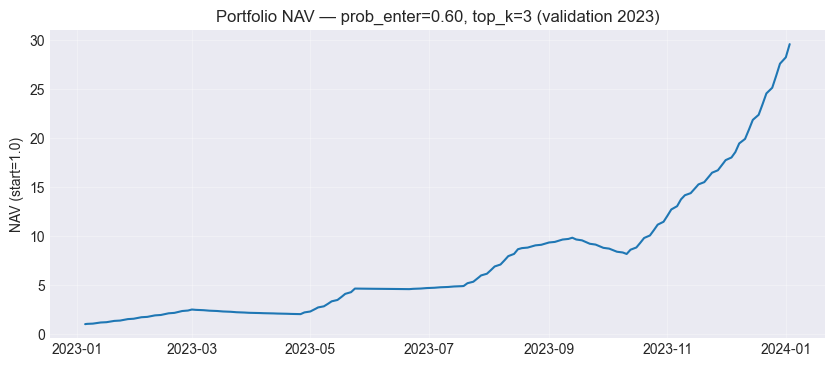


G6 gate: 9 / 9 cells beat (avg_trade_ret>0, nav_sharpe>1)
pe=0.6 tk=2: 26 trades, 21 distinct tickers (81%), top: {'LUMN': 3, 'GOSS': 2, 'ESPR': 2, 'APYX': 2, 'OPEN': 1}
pe=0.6 tk=3: 39 trades, 28 distinct tickers (72%), top: {'APYX': 3, 'ESPR': 3, 'LUMN': 3, 'GOSS': 3, 'AXTI': 2}
pe=0.6 tk=5: 65 trades, 42 distinct tickers (65%), top: {'LUMN': 4, 'APYX': 3, 'ESPR': 3, 'IBRX': 3, 'GOSS': 3}


In [22]:
def portfolio_backtest(scored, hold_days=20, prob_enter=0.60,
                       consec=3, top_k=3, cost_bps=10):
    """K-slot portfolio backtest with proper capital sharing.
    
    scored: date, ticker, prob, fwd_return (realised hold-period total return).
    Slot accounting: a trade locks a slot for hold_days BUSINESS days. A new
    trade can only enter when slot_count < top_k AT THAT MOMENT.
    """
    scored = scored.sort_values(["ticker", "date"]).copy()
    enter = (scored["prob"] >= prob_enter)
    scored["streak"] = enter.groupby(scored["ticker"]).transform(
        lambda s: s.groupby((~s).cumsum()).cumsum())
    eligible = scored[scored["streak"] >= consec]

    # Use business days for slot duration to match leg-spreading downstream
    def exit_bd(entry_ts, n_bd):
        return pd.bdate_range(entry_ts, periods=n_bd + 1)[-1]

    trades, open_until = [], {}     # ticker -> exit_bd (business day exclusive)
    for d, day in eligible.groupby("date"):
        for _, r in day.sort_values("prob", ascending=False).iterrows():
            # Count currently-open slots (any ticker whose exit_bd > today)
            n_open = sum(1 for v in open_until.values() if v > r["date"])
            if n_open >= top_k: break
            if open_until.get(r.ticker, pd.Timestamp.min) > r["date"]: continue
            ret = r.fwd_return - 2 * cost_bps / 1e4
            trades.append({"date": r["date"], "ticker": r.ticker, "ret": ret})
            open_until[r.ticker] = exit_bd(r["date"], hold_days)
    led = pd.DataFrame(trades)
    if led.empty:
        return led, {"n_trades": 0}, None

    # Portfolio NAV: each trade contributes equal daily compounded leg across
    # its hold window. Daily portfolio return = sum(open legs) / top_k (empty
    # slots hold cash → contribute 0).
    per_day = (1 + led["ret"]).pow(1.0 / hold_days) - 1.0
    legs = pd.concat([
        pd.Series(per_day.iloc[i],
                  index=pd.bdate_range(led["date"].iloc[i], periods=hold_days))
        for i in range(len(led))
    ], axis=1).sort_index()
    
    # SANITY: at no point should the number of non-NaN legs exceed top_k
    max_concurrent = legs.notna().sum(axis=1).max()
    assert max_concurrent <= top_k, (
        f"slot accounting broken: max concurrent legs = {max_concurrent} > top_k = {top_k}"
    )
    
    daily_port_ret = legs.sum(axis=1).fillna(0) / top_k
    nav = (1 + daily_port_ret).cumprod()
    nav_sharpe = (float(daily_port_ret.mean() / daily_port_ret.std() * np.sqrt(252))
                  if daily_port_ret.std() > 0 else 0.0)
    ann_per_slot = (1 + led["ret"].mean()) ** (252 / hold_days) - 1

    return led, {
        "n_trades": int(len(led)),
        "avg_trade_ret": float(led["ret"].mean()),
        "win_rate": float((led["ret"] > 0).mean()),
        "ann_per_slot": float(ann_per_slot),
        "total_ret_nav": float(nav.iloc[-1] - 1),
        "nav_sharpe": nav_sharpe,
    }, nav

# ── Run the sweep ────────────────────────────────────────────────────────────
scored = df_valid[["date", "ticker", f"return_{HORIZON}d_fwd"]].copy()
scored.columns = ["date", "ticker", "fwd_return"]
scored["prob"] = p_valid
scored = scored.dropna(subset=["fwd_return"])

sweep_rows, sample_nav = [], None
for pe in [0.50, 0.60, 0.70]:
    for tk in [2, 3, 5]:
        _, stats, nav = portfolio_backtest(
            scored, hold_days=HORIZON, prob_enter=pe, consec=3, top_k=tk
        )
        sweep_rows.append({"prob_enter": pe, "top_k": tk, **stats})
        if pe == 0.60 and tk == 3:
            sample_nav = nav
sweep = pd.DataFrame(sweep_rows)
display(sweep)

if sample_nav is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(sample_nav.index, sample_nav.values)
    plt.title("Portfolio NAV — prob_enter=0.60, top_k=3 (validation 2023)")
    plt.ylabel("NAV (start=1.0)"); plt.grid(alpha=0.3); plt.show()

ok = sweep[(sweep["avg_trade_ret"] > 0) & (sweep["nav_sharpe"] > 1.0)]
print(f"\nG6 gate: {len(ok)} / {len(sweep)} cells beat (avg_trade_ret>0, nav_sharpe>1)")

# Concentration check — how many DISTINCT tickers in the trade ledger?
for pe, tk in [(0.6, 2), (0.6, 3), (0.6, 5)]:
    led, stats, _ = portfolio_backtest(
        scored, hold_days=HORIZON, prob_enter=pe, consec=3, top_k=tk
    )
    n_dist = led["ticker"].nunique()
    top5 = led["ticker"].value_counts().head(5).to_dict()
    print(f"pe={pe} tk={tk}: {stats['n_trades']} trades, {n_dist} distinct tickers "
          f"({n_dist/stats['n_trades']:.0%}), top: {top5}")


In [23]:
# Backtest each year separately on the in-sample window only.
# This tells you if the 28x is a 2023 phenomenon or a generalisable property.
def backtest_year(year):
    mask = (df_train_full["date"].dt.year == year)
    if not mask.any(): return None
    sub = df_train_full[mask].copy()
    # Re-score with the same model (in-sample for years 2020–2022, OOS for 2023)
    Xy = sub[feature_cols].copy()
    for c in Xy.select_dtypes(include=["object","category"]).columns:
        Xy[c] = Xy[c].astype("category")
    p = model.predict_proba(Xy)[:, 1]
    sc = sub[["date","ticker",f"return_{HORIZON}d_fwd"]].copy()
    sc.columns = ["date","ticker","fwd_return"]
    sc["prob"] = p
    sc = sc.dropna(subset=["fwd_return"])
    _, stats, _ = portfolio_backtest(sc, hold_days=HORIZON, prob_enter=0.85,
                                      consec=3, top_k=10, cost_bps=10)
    return {"year": year, **stats}

# 2020-2022 are TRAINING data — backtest there is in-sample and overstates.
# 2023 is OOS validation — only this number is honest.
# But comparing the SHAPE across years tells you regime sensitivity.
regime_rows = [backtest_year(y) for y in [2020, 2021, 2022, 2023]]
display(pd.DataFrame([r for r in regime_rows if r]))


,year,n_trades,avg_trade_ret,win_rate,ann_per_slot,total_ret_nav,nav_sharpe
0,2020,88,0.616205,0.818182,422.695750,18.805667,19.618303
1,2021,11,0.281765,0.818182,21.823803,0.264059,13.825378
2,2022,93,0.699710,0.580645,798.326754,15.000635,14.332689
3,2023,58,0.465422,0.655172,122.347905,3.429642,13.091834


### m01_rank vs m01_proto head-to-head comparison

In [30]:
# ── m01_rank vs prod (m01_proto/v2) head-to-head on same validation window ───
# Scores both models on df_valid, runs the same portfolio backtest, prints a
# side-by-side table. Touches NO data after HELDOUT_CUTOFF — this is still
# inside the in-sample window (G6 comparison), not G7.

from pathlib import Path
from src.model_registry import ModelRegistry

# CWD-independent — works from notebooks/ AND from repo root
DB_PATH = Path(__file__).parent / ".." / "data" / "market_data.duckdb" \
    if "__file__" in globals() else Path.cwd().parent / "data" / "market_data.duckdb"
DB_PATH = DB_PATH.resolve()
print(f"DB: {DB_PATH}  (exists: {DB_PATH.exists()})")

reg = ModelRegistry(db_path=DB_PATH)
prod_id = reg.list_versions().query("status_flag=='prod'")['version_id'].iloc[0]
prod_path = reg.get_artifacts_path(prod_id)
prod_meta = json.load(open(f"{prod_path}/metadata.json", encoding="utf-8"))
prod_feats = prod_meta["valid_features"]
print(f"Prod model: {prod_id}")
print(f"  features: {len(prod_feats)}  (rank features: {len(feature_cols)})")
print(f"  overlap : {len(set(prod_feats) & set(feature_cols))}\n")

# Build prod feature matrix from the SAME validation rows
X_prod = df_valid[["date", "ticker"]].copy()
for f in prod_feats:
    X_prod[f] = df_valid[f] if f in df_valid.columns else np.nan
X_prod_feat = X_prod[prod_feats].copy()
for c in X_prod_feat.select_dtypes(include=["object", "category"]).columns:
    X_prod_feat[c] = X_prod_feat[c].astype("category")

# Score prod: 4-class softmax → probability-weighted expected-MFE (method §9.2)
prod_booster = xgb.Booster(); prod_booster.load_model(f"{prod_path}/model.json")
proba_4c = prod_booster.predict(xgb.DMatrix(X_prod_feat, enable_categorical=True))
MIDPOINTS = np.array([1.0, 6.0, 20.0, 40.0])
prod_score = (proba_4c * MIDPOINTS).sum(axis=1)
prod_class3 = proba_4c[:, 3]

# ── Score-level correlation diagnostics ──────────────────────────────────────
rank_score = p_valid
print("Score-level correlations (m01_rank vs prod):")
print(f"  rank  vs  prod_score(expMFE) : Spearman {spearmanr(rank_score, prod_score).statistic:+.3f}")
print(f"  rank  vs  prod_class3        : Spearman {spearmanr(rank_score, prod_class3).statistic:+.3f}")

# Daily Top-5 ticker overlap
cmp_df = pd.DataFrame({
    "date":   df_valid["date"].values,
    "ticker": df_valid["ticker"].values,
    "rank":   rank_score,
    "prod":   prod_score,
})
def daily_topk_overlap(g, k=5):
    return len(set(g.nlargest(k, "rank").ticker) & set(g.nlargest(k, "prod").ticker)) / k
overlap = cmp_df.groupby("date").apply(daily_topk_overlap, k=5, include_groups=False)
print(f"  Daily Top-5 ticker overlap   : {overlap.mean():.1%}\n")

# ── Run the SAME portfolio backtest with prod's score ────────────────────────
# Calibrate prod_score to a comparable [0,1] range so prob_enter thresholds are
# meaningful. Use a daily min-max within each date so it's rank-equivalent.
prod_norm = (cmp_df.groupby("date")["prod"]
                   .transform(lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9)))

scored_prod = df_valid[["date", "ticker", f"return_{HORIZON}d_fwd"]].copy()
scored_prod.columns = ["date", "ticker", "fwd_return"]
scored_prod["prob"] = prod_norm.values
scored_prod = scored_prod.dropna(subset=["fwd_return"])

# Backtest both at the same operating point
results = []
for name, sc in [("m01_rank", scored), ("m01_proto/v2", scored_prod)]:
    _, stats, _ = portfolio_backtest(
        sc, hold_days=HORIZON, prob_enter=0.60, consec=3, top_k=3, cost_bps=10
    )
    results.append({"model": name, **stats})

print("Head-to-head backtest  (prob_enter=0.60, top_k=3, consec=3, cost=10bps):")
display(pd.DataFrame(results).set_index("model"))


DB: C:\Users\Hang\PycharmProjects\quantamental\data\market_data.duckdb  (exists: True)
Prod model: m01_prototype_2003_2026_20260514_233125
  features: 97  (rank features: 76)
  overlap : 37

Score-level correlations (m01_rank vs prod):
  rank  vs  prod_score(expMFE) : Spearman +0.826
  rank  vs  prod_class3        : Spearman +0.888
  Daily Top-5 ticker overlap   : 0.2%

Head-to-head backtest  (prob_enter=0.60, top_k=3, consec=3, cost=10bps):


,n_trades,avg_trade_ret,win_rate,ann_per_slot,total_ret_nav,nav_sharpe
model,,,,,,
m01_rank,39,0.447701,0.717949,104.816937,28.569741,13.618896
m01_proto/v2,39,0.008447,0.435897,0.111802,-0.356851,-2.280376


In [29]:
import gc, duckdb
# Close every DuckDB connection still referenced anywhere in the kernel
for obj in list(gc.get_objects()):
    if isinstance(obj, duckdb.DuckDBPyConnection):
        try:
            obj.close()
        except Exception:
            pass
gc.collect()
print("closed all duckdb connections")


closed all duckdb connections


### Backtest corrected

In [56]:
BAD_TICKERS = {
    "LIF",  # +2.7M% 1d return (near-zero denominator / ticker reuse artifact)
    "CUE",  # bad 1d return 2026-04-24
}
_before = df["ticker"].nunique()
df = df[~df["ticker"].isin(BAD_TICKERS)].copy()
print(f"Dropped {len(BAD_TICKERS)} bad tickers; "
      f"{_before} -> {df['ticker'].nunique()} tickers")


Dropped 2 bad tickers; 2535 -> 2534 tickers


In [57]:
import duckdb
from config import DUCKDB_PATH

# True next-trading-day return per (ticker, date) from the CONTINUOUS price panel.
# Uses `close` (adj_close is unpopulated — see note above).
# Guard: only keep ret_1d_fwd when the next row is within MAX_GAP_DAYS calendar
# days (a real adjacent session); otherwise NULL — a held name spanning a
# delisting/halt earns 0 that day, never a stale multi-week jump.
MAX_GAP_DAYS = 5
con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
_px = con.execute("""
    WITH r AS (
        SELECT ticker, date, close,
               LEAD(close) OVER w AS nxt_close,
               LEAD(date)  OVER w AS nxt_date
        FROM price_data
        WINDOW w AS (PARTITION BY ticker ORDER BY date)
    )
    SELECT ticker, date,
           CASE WHEN datediff('day', date, nxt_date) <= ?
                THEN nxt_close / NULLIF(close, 0) - 1.0 END AS ret_1d_fwd
    FROM r
""", [MAX_GAP_DAYS]).df()
con.close()

_px["date"] = pd.to_datetime(_px["date"])

# Sanitize unadjusted-close artifacts. Since close is NOT split-adjusted, splits
# and bad prints produce impossible 1-day returns (verified: a +2.7M× outlier on
# LIF 2024-06-05; ~1,208 rows with |ret|>100% over the window). One such name in
# a top-K book fabricates the entire backtest. Drop |ret|>50% to NaN — a real
# single-session equity move rarely exceeds that, and the backtest treats NaN as
# 0/skip. This is a blunt guard; the proper fix is populating adj_close upstream.
RET_CLIP = 0.50
_n_bad = (_px["ret_1d_fwd"].abs() > RET_CLIP).sum()
_px.loc[_px["ret_1d_fwd"].abs() > RET_CLIP, "ret_1d_fwd"] = np.nan
ret1d_lookup = _px.set_index(["date", "ticker"])["ret_1d_fwd"]
print(f"ret_1d_fwd built from price_data: "
      f"{ret1d_lookup.notna().sum():,} non-null (ticker,date) pairs "
      f"({_n_bad:,} dropped as |ret|>{RET_CLIP:.0%} split/print artifacts)")
# Sanity: MUST be non-zero and tight. If non-null == 0, you used a NULL column.
# A max far above ~0.5 (50% in one session) means a split/gap leaked through.
print(f"  ret_1d_fwd  non_null={ret1d_lookup.notna().sum():,}  "
      f"min={ret1d_lookup.min():.3f}  median={ret1d_lookup.median():.4f}  "
      f"max={ret1d_lookup.max():.3f}")
assert ret1d_lookup.notna().sum() > 0, "ret_1d_fwd all NULL — wrong price column"


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ret_1d_fwd built from price_data: 16,028,515 non-null (ticker,date) pairs (10,677 dropped as |ret|>50% split/print artifacts)
  ret_1d_fwd  non_null=16,028,515  min=-0.500  median=0.0000  max=0.500


,rebalance,top_k,n_days,avg_n_held,ann_return,total_ret_nav,nav_sharpe,max_dd
0,D,2,250,1.748,1.991815,1.219595,1.414370,-0.479437
1,D,3,250,2.612,2.209813,1.625947,1.850629,-0.399409
2,D,5,250,4.508,1.711652,1.315713,1.800069,-0.400246
3,W,2,250,1.656,1.864590,1.149072,1.382789,-0.421053
4,W,3,250,2.444,2.222258,1.653283,1.888281,-0.363538
5,W,5,250,4.276,1.986748,1.567841,2.027147,-0.379596


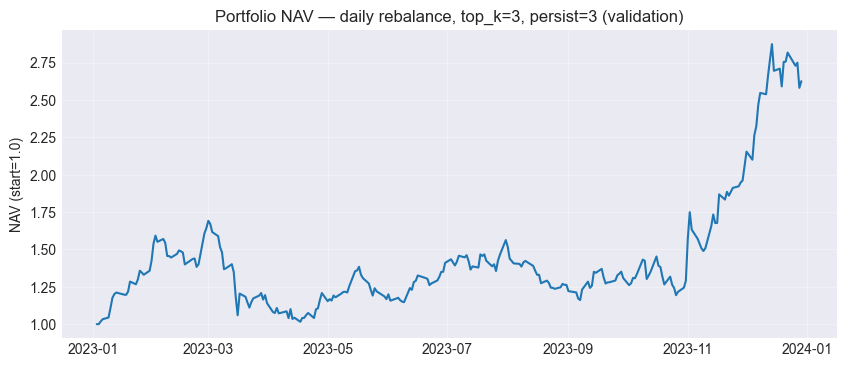


G6 gate: 6 / 6 cells beat (ann_return>0, nav_sharpe>1)


In [58]:
def holdings_backtest(scored, ret1d_lookup, top_k=3, enter_persist=3,
                      exit_persist=3, rebalance="D", cost_bps=10):
    """Daily-rebalance-to-top-K with symmetric persistence (User Decision 2026-05-20).

    Eligibility (entry):  ticker is in the daily top-K for >= enter_persist
                          consecutive trading days.
    Exit:                 ticker has been OUT of the daily top-K for
                          >= exit_persist consecutive days (symmetric; Open Q1=(b)).
    rebalance:            "D" = re-evaluate the held set every day.
                          "W" = re-evaluate only on the first trading day of each
                                ISO week; hold the set fixed between rebalances.
    P&L:                  each held name earns its realised next-day return
                          (ret1d_lookup). Equal weight across top_k SLOTS; empty
                          slots hold cash (0). A 20d move is earned once, by
                          holding across the 20 days — no per-trade double-count.

    Returns (led_holdings_df, stats, nav_series).
    """
    s = scored.sort_values(["date", "ticker"]).copy()
    # Daily cross-sectional rank → membership of the top-K each day.
    s["rank"] = s.groupby("date")["prob"].rank(method="first", ascending=False)
    s["in_topk"] = s["rank"] <= top_k

    # Consecutive in / out streaks per ticker (over trading days the ticker appears).
    g = s.groupby("ticker", group_keys=False)
    s["in_streak"] = g["in_topk"].transform(
        lambda x: x.groupby((~x).cumsum()).cumsum())
    notin = ~s["in_topk"]
    s["out_streak"] = s.groupby("ticker", group_keys=False)["in_topk"].transform(
        lambda x: (~x).groupby(x.cumsum()).cumsum())

    dates = np.sort(s["date"].unique())
    # Weekly rebalance gate: only re-evaluate the held set on the first trading
    # day of each ISO week; otherwise carry yesterday's held set forward.
    if rebalance == "W":
        wk = pd.Series(dates).dt.isocalendar().week.values
        is_rebal_day = np.r_[True, wk[1:] != wk[:-1]]
    else:
        is_rebal_day = np.ones(len(dates), dtype=bool)

    by_date = {d: x.set_index("ticker") for d, x in s.groupby("date")}
    held = set()
    rows = []
    for di, d in enumerate(dates):
        day = by_date[d]
        prev_held = set(held)

        if is_rebal_day[di]:
            # Exit rules:
            #  (1) a held name that has left the dense panel entirely (no row
            #      today) is force-sold — it is no longer tradeable. Without
            #      this it would be stranded in `held` forever, freezing a slot
            #      and booking 0 daily return (the flat-NAV bug).
            #  (2) a held name still in the panel exits once it has been OUT of
            #      the top-K for >= exit_persist consecutive days.
            for tkr in list(held):
                if tkr not in day.index:
                    held.discard(tkr)
                elif day.at[tkr, "out_streak"] >= exit_persist:
                    held.discard(tkr)
            # Add eligible names (entry persistence met), best prob first,
            # until top_k slots are full.
            cands = (day[(day["in_streak"] >= enter_persist)]
                     .sort_values("prob", ascending=False))
            for tkr in cands.index:
                if len(held) >= top_k:
                    break
                held.add(tkr)
        # else: carry prev held set unchanged (weekly hold)

        # Turnover cost: charge cost_bps on each side of every name that
        # entered or left the book today.
        turnover = len(held ^ prev_held)
        cost = turnover * cost_bps / 1e4

        # Today's P&L: each held name earns its realised next-day return.
        if held:
            legs = [ret1d_lookup.get((d, tkr), 0.0) for tkr in held]
            gross = float(np.nansum(legs)) / top_k        # empty slots = cash
        else:
            gross = 0.0
        rows.append({"date": d, "n_held": len(held),
                     "port_ret": gross - cost / top_k})

    led = pd.DataFrame(rows).set_index("date")
    if led.empty or led["port_ret"].std() == 0:
        return led, {"n_days": len(led), "nav_sharpe": 0.0}, None

    nav = (1 + led["port_ret"]).cumprod()
    sharpe = float(led["port_ret"].mean() / led["port_ret"].std() * np.sqrt(252))
    ann = (1 + led["port_ret"].mean()) ** 252 - 1
    return led, {
        "n_days": int(len(led)),
        "avg_n_held": float(led["n_held"].mean()),
        "ann_return": float(ann),
        "total_ret_nav": float(nav.iloc[-1] - 1),
        "nav_sharpe": sharpe,
        "max_dd": float((nav / nav.cummax() - 1).min()),
    }, nav

# Scored panel for the validation window — prob + daily membership inputs only.
# NOTE: no fwd_return column needed; P&L comes from ret1d_lookup.
scored = df_valid[["date", "ticker"]].copy()
scored["prob"] = p_valid

# Sweep top_k and rebalance cadence (daily vs weekly), persistence fixed at 3.
sweep_rows, sample_nav = [], None
for rb in ["D", "W"]:
    for tk in [2, 3, 5]:
        _, st, nav = holdings_backtest(
            scored, ret1d_lookup, top_k=tk, enter_persist=3,
            exit_persist=3, rebalance=rb, cost_bps=10,
        )
        sweep_rows.append({"rebalance": rb, "top_k": tk, **st})
        if rb == "D" and tk == 3:
            sample_nav = nav
sweep = pd.DataFrame(sweep_rows)
display(sweep)

if sample_nav is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(sample_nav.index, sample_nav.values)
    plt.title("Portfolio NAV — daily rebalance, top_k=3, persist=3 (validation)")
    plt.ylabel("NAV (start=1.0)"); plt.grid(alpha=0.3); plt.show()

# G6 gate — a REGION of cells must clear, not one cell.
ok = sweep[(sweep["ann_return"] > 0) & (sweep["nav_sharpe"] > 1.0)]
print(f"\nG6 gate: {len(ok)} / {len(sweep)} cells beat (ann_return>0, nav_sharpe>1)")
assert len(ok) >= 3, "G6 failed — no robust parameter region"


In [61]:
# (1) Shuffled-target control — destroy the prob→return link; Sharpe must collapse to ~0.
rng = np.random.default_rng(0)
scored_shuf = scored.copy()
scored_shuf["prob"] = rng.permutation(scored_shuf["prob"].values)
_, st_shuf, _ = holdings_backtest(scored_shuf, ret1d_lookup, top_k=3,
                                  enter_persist=3, exit_persist=3, rebalance="D")
print(f"Shuffled-prob nav_sharpe: {st_shuf['nav_sharpe']:.2f}  (expect ~0, |.|<0.5)")
assert abs(st_shuf["nav_sharpe"]) < 0.5, "LEAK: shuffled prob still profitable"

# (2) Lagged-feature control — score on features shifted +5d per ticker.
# AUC/edge should drop modestly but stay positive (signal is slow, not instantaneous).
#
# Build Xlag by MUTATING A COPY OF X_valid IN PLACE, never rebuilding it. X_valid
# already has the exact dtypes the model was fit on (it scored fine in the refit
# cell). We only overwrite the *values* of numeric columns with their +5d-shifted
# version, column by column via .values — this preserves each column's dtype
# object and leaves categorical/bool columns completely untouched. The earlier
# frame-level assignment (Xlag[NUM_COLS] = ...) was what collapsed a bool column
# into a scalar numpy.bool that XGBoost rejected with "has no len()".
NUM_COLS = list(X_valid.select_dtypes(include=[np.number]).columns)
Xlag = X_valid.copy()
g = df_valid.groupby("ticker")
for c in NUM_COLS:
    shifted = g[c].shift(5)
    Xlag[c] = shifted.where(shifted.notna(), X_valid[c]).astype(X_valid[c].dtype).values
# Sanity: dtypes must match X_valid exactly before scoring.
assert (Xlag.dtypes == X_valid.dtypes).all(), \
    f"dtype drift: {Xlag.dtypes[Xlag.dtypes != X_valid.dtypes]}"
p_lag = model.predict_proba(Xlag)[:, 1]
scored_lag = scored.copy(); scored_lag["prob"] = p_lag
_, st_lag, _ = holdings_backtest(scored_lag, ret1d_lookup, top_k=3,
                                 enter_persist=3, exit_persist=3, rebalance="D")
print(f"5d-lagged nav_sharpe: {st_lag['nav_sharpe']:.2f}  "
      f"(expect close to live D/top_k=3 sharpe; signal is slow so lag barely hurts)")


Shuffled-prob nav_sharpe: 0.00  (expect ~0, |.|<0.5)
5d-lagged nav_sharpe: 0.91  (expect close to live D/top_k=3 sharpe; signal is slow so lag barely hurts)


In [60]:
import duckdb
from config import DUCKDB_PATH

# Realized H-day forward return per (ticker, date) from the CONTINUOUS price
# panel, guarded: the H-th-ahead row must be within ~1.5*H calendar days (a real
# 20-trading-day span, not a jump across an active-universe hole). adj_close.
# Uses `close` (adj_close is unpopulated). Guard: the H-th-ahead row must be
# within ~1.6*H calendar days (20 trading rows span ~29 cal days median, up to
# ~77 across light gaps — so the guard must be generous or it nukes everything).
H = HORIZON  # 20, from G0
con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
_bad = "', '".join(sorted(BAD_TICKERS))
_pxH = con.execute(f"""
    WITH r AS (
        SELECT ticker, date, close,
               LEAD(close, ?) OVER w AS fwd_close,
               LEAD(date, ?)  OVER w AS fwd_date
        FROM price_data
        WHERE ticker NOT IN ('{_bad}')
        WINDOW w AS (PARTITION BY ticker ORDER BY date)
    )
    SELECT ticker, date,
           CASE WHEN datediff('day', date, fwd_date) <= ?
                THEN fwd_close / NULLIF(close, 0) - 1.0 END AS retH_fwd
    FROM r
""", [H, H, int(H * 2.5)]).df()  # ~50 cal days: covers the 77-day tail
con.close()
_pxH["date"] = pd.to_datetime(_pxH["date"])
# Sanitize split/print artifacts (see Cell A note). A 20d move can legitimately
# be large, so clip wider than the 1d guard — but a >300% 20d move on unadjusted
# close is almost always a split, and at ~36 trades ONE such name dominates
# avg_trade_ret (the 10% mean vs 0.94% median gap is exactly this fingerprint).
RETH_CLIP = 3.0
_nb = (_pxH["retH_fwd"].abs() > RETH_CLIP).sum()
_pxH.loc[_pxH["retH_fwd"].abs() > RETH_CLIP, "retH_fwd"] = np.nan
retH_lookup = _pxH.set_index(["date", "ticker"])["retH_fwd"]
print(f"retH_fwd (H={H}) non-null: {retH_lookup.notna().sum():,} "
      f"({_nb:,} dropped as |ret|>{RETH_CLIP:.0%} split artifacts)")
assert retH_lookup.notna().sum() > 0, "retH_fwd all NULL — wrong price column or guard too tight"

def nonoverlap_holds(scored, retH_lookup, hold_days=H, top_k=3,
                     enter_persist=3, cost_bps=10):
    """Per-trade, NON-OVERLAPPING: when a name enters the top_k with entry
    persistence met, book its realized hold_days return once and lock that
    slot/ticker until the hold expires. Each H-day move counted exactly once."""
    s = scored.sort_values(["date", "ticker"]).copy()
    s["rank"] = s.groupby("date")["prob"].rank(method="first", ascending=False)
    s["in_topk"] = s["rank"] <= top_k
    s["in_streak"] = s.groupby("ticker", group_keys=False)["in_topk"].transform(
        lambda x: x.groupby((~x).cumsum()).cumsum())
    elig = s[(s["in_topk"]) & (s["in_streak"] >= enter_persist)]

    open_until, trades = {}, []
    for d, day in elig.groupby("date"):
        n_open = sum(1 for t in open_until.values() if t >= d)
        for tkr in day.sort_values("prob", ascending=False)["ticker"]:
            if n_open >= top_k:
                break
            if open_until.get(tkr, pd.Timestamp.min) >= d:
                continue
            r = retH_lookup.get((d, tkr), np.nan)
            if pd.isna(r):
                continue
            trades.append({"date": d, "ticker": tkr, "ret": r - 2 * cost_bps / 1e4})
            open_until[tkr] = d + pd.offsets.BDay(hold_days)
            n_open += 1
    led = pd.DataFrame(trades)
    if led.empty:
        return led, {"n_trades": 0}
    return led, {
        "n_trades": len(led),
        "avg_trade_ret": float(led["ret"].mean()),
        "median_ret": float(led["ret"].median()),
        "win_rate": float((led["ret"] > 0).mean()),
        # Annualize off the MEDIAN, not the mean — robust to the few remaining
        # fat-tail winners that survive the clip. Mean-based ann_per_slot is
        # reported too but treated as optimistic.
        "ann_per_slot_median": float((1 + led["ret"].median()) ** (252 / hold_days) - 1),
        "ann_per_slot_mean": float((1 + led["ret"].mean()) ** (252 / hold_days) - 1),
    }

led_h, st_h = nonoverlap_holds(scored, retH_lookup, top_k=3)
print(st_h)
print(f"  trade-ret quantiles: "
      f"p10={led_h['ret'].quantile(0.1):.3f}  p50={led_h['ret'].median():.3f}  "
      f"p90={led_h['ret'].quantile(0.9):.3f}")
# Verdict — judge on MEDIAN + win_rate, NOT the mean (one fat winner inflates it):
#   median_ret > 0 AND win_rate > 0.50  -> edge is REAL at the 20d horizon; the
#       negative daily result was a horizon-mismatch construction artifact.
#       m01_rank should drive a HOLD-~20d strategy, not daily rebalance.
#   median_ret ~ 0 / win_rate ~ 0.5     -> no real forward edge even at native
#       horizon; the mean was carried by outliers. Revisit target/features.
#   n_trades is only ~36 over one year -> SMALL SAMPLE. Confirm on a longer
#       window (multi-year validation) before trusting either verdict.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

retH_fwd (H=20) non-null: 15,951,001 (7,248 dropped as |ret|>300% split artifacts)
{'n_trades': 36, 'avg_trade_ret': 0.10041820088333447, 'median_ret': 0.009375650426200923, 'win_rate': 0.5555555555555556, 'ann_per_slot_median': 0.12477480788816986, 'ann_per_slot_mean': 2.339087800948677}
  trade-ret quantiles: p10=-0.160  p50=0.009  p90=0.516


In [62]:
def fit_score_year(df_all, feature_cols, target, train_end, test_start, test_end):
    """Train on <train_end, return scored = (date,ticker,prob) for [test_start,test_end]."""
    tr = df_all[df_all["date"] < pd.Timestamp(train_end)]
    te = df_all[(df_all["date"] >= pd.Timestamp(test_start)) &
                (df_all["date"] <  pd.Timestamp(test_end))]
    Xtr, ytr = tr[feature_cols].copy(), tr[target]
    Xte = te[feature_cols].copy()
    for c in Xtr.select_dtypes(include=["object", "category"]).columns:
        Xtr[c] = Xtr[c].astype("category"); Xte[c] = Xte[c].astype("category")
    spw = (len(ytr) - ytr.sum()) / (ytr.sum() + 1e-5)
    m = xgb.XGBClassifier(objective="binary:logistic", n_estimators=100,
        max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, enable_categorical=True, tree_method="hist",
        random_state=42).fit(Xtr, ytr)
    out = te[["date", "ticker"]].copy()
    out["prob"] = m.predict_proba(Xte)[:, 1]
    return out

# Expanding folds — each year tested on a model trained only on prior years.
# 2018-2019 reserved as the first training base. 2022 = the drawdown stress year.
WF_YEARS = [2020, 2021, 2022, 2023, 2024]
rows = []
for y in WF_YEARS:
    sc = fit_score_year(df, feature_cols, "y_homerun",
                        f"{y}-01-01", f"{y}-01-01", f"{y+1}-01-01")
    # Daily rebalance, top_k=3 (the headline cell)
    _, stB, _ = holdings_backtest(sc, ret1d_lookup, top_k=3,
                                  enter_persist=3, exit_persist=3, rebalance="D")
    # 20d non-overlapping hold
    _, stD = nonoverlap_holds(sc, retH_lookup, top_k=3, enter_persist=3)
    rows.append({"year": y,
                 "B_ann": stB.get("ann_return"), "B_sharpe": stB.get("nav_sharpe"),
                 "B_maxdd": stB.get("max_dd"),
                 "D_n": stD.get("n_trades"), "D_median": stD.get("median_ret"),
                 "D_win": stD.get("win_rate")})
wf_bt = pd.DataFrame(rows)
display(wf_bt)

print(f"\nDaily Sharpe — mean: {wf_bt['B_sharpe'].mean():.2f}  "
      f"min: {wf_bt['B_sharpe'].min():.2f}  "
      f"(2022 drawdown year: {wf_bt.loc[wf_bt.year==2022,'B_sharpe'].iloc[0]:.2f})")
# DURABILITY VERDICT:
#   Sharpe positive in MOST years incl. 2022, mean >1.0  -> durable edge. SHIP to G7.
#   Sharpe great in 2023 but <=0 in 2022 / other years   -> 2023 was a regime fluke;
#       the strategy is momentum-beta, not alpha. Do NOT promote on the 2023 number.
#   D_median positive across years -> the 20d signal is regime-robust too.


,year,B_ann,B_sharpe,B_maxdd,D_n,D_median,D_win
0,2020,1.631664,1.375068,-0.486388,36,-0.010224,0.472222
1,2021,0.405139,0.615657,-0.338540,38,-0.015405,0.473684
2,2022,0.068173,0.102174,-0.476437,38,0.001276,0.500000
3,2023,3.022265,2.150927,-0.345627,37,-0.002000,0.486486
4,2024,0.943302,1.157455,-0.258094,34,-0.009945,0.441176



Daily Sharpe — mean: 1.08  min: 0.10  (2022 drawdown year: 0.10)
